In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/processed/wine_processed.csv")

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [4]:
rf_pred = rf_model.predict(X_test)

In [5]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.5735294117647058


In [6]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.64      0.62      0.63        87
           6       0.54      0.63      0.58        82
           7       0.52      0.46      0.49        24
           8       0.00      0.00      0.00         3

    accuracy                           0.57       204
   macro avg       0.28      0.29      0.28       204
weighted avg       0.55      0.57      0.56       204



c:\Users\Diya\OneDrive\Desktop\ML\Wine Quality Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Diya\OneDrive\Desktop\ML\Wine Quality Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Diya\OneDrive\Desktop\ML\Wine Quality Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [7]:
print(confusion_matrix(y_test, rf_pred))

[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 54 31  2  0]
 [ 0  1 23 52  6  0]
 [ 0  0  2 10 11  1]
 [ 0  0  0  1  2  0]]


In [8]:
results = {}

results["Random Forest"] = accuracy_score(
    y_test,
    rf_pred
)

results

{'Random Forest': 0.5735294117647058}

In [9]:
sgd_model = SGDClassifier(
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [10]:
sgd_pred = sgd_model.predict(X_test_scaled)

In [11]:
print("SGD Accuracy:", accuracy_score(y_test, sgd_pred))

print(classification_report(y_test, sgd_pred))

print(confusion_matrix(y_test, sgd_pred))

SGD Accuracy: 0.5343137254901961
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.56      0.72      0.63        87
           6       0.53      0.52      0.53        82
           7       0.50      0.08      0.14        24
           8       1.00      0.33      0.50         3

    accuracy                           0.53       204
   macro avg       0.43      0.28      0.30       204
weighted avg       0.52      0.53      0.50       204

[[ 0  0  1  0  0  0]
 [ 0  0  5  2  0  0]
 [ 1  1 63 21  1  0]
 [ 0  2 37 43  0  0]
 [ 0  1  7 14  2  0]
 [ 0  0  0  1  1  1]]


In [12]:
results["SGD"] = accuracy_score(y_test, sgd_pred)

results

{'Random Forest': 0.5735294117647058, 'SGD': 0.5343137254901961}

In [13]:
svc_model = SVC(
    kernel="rbf",
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [14]:
svc_pred = svc_model.predict(X_test_scaled)

In [15]:
print("SVC Accuracy:", accuracy_score(y_test, svc_pred))

print(classification_report(y_test, svc_pred))

print(confusion_matrix(y_test, svc_pred))

SVC Accuracy: 0.6029411764705882
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.65      0.75      0.70        87
           6       0.56      0.60      0.58        82
           7       0.56      0.38      0.45        24
           8       0.00      0.00      0.00         3

    accuracy                           0.60       204
   macro avg       0.29      0.29      0.29       204
weighted avg       0.57      0.60      0.58       204

[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 65 22  0  0]
 [ 0  0 28 49  5  0]
 [ 0  0  2 13  9  0]
 [ 0  0  0  1  2  0]]


c:\Users\Diya\OneDrive\Desktop\ML\Wine Quality Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Diya\OneDrive\Desktop\ML\Wine Quality Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Diya\OneDrive\Desktop\ML\Wine Quality Prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [16]:
results["SVC"] = accuracy_score(y_test, svc_pred)

results

{'Random Forest': 0.5735294117647058,
 'SGD': 0.5343137254901961,
 'SVC': 0.6029411764705882}

In [17]:
results_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

           Model  Accuracy
2            SVC  0.602941
0  Random Forest  0.573529
1            SGD  0.534314


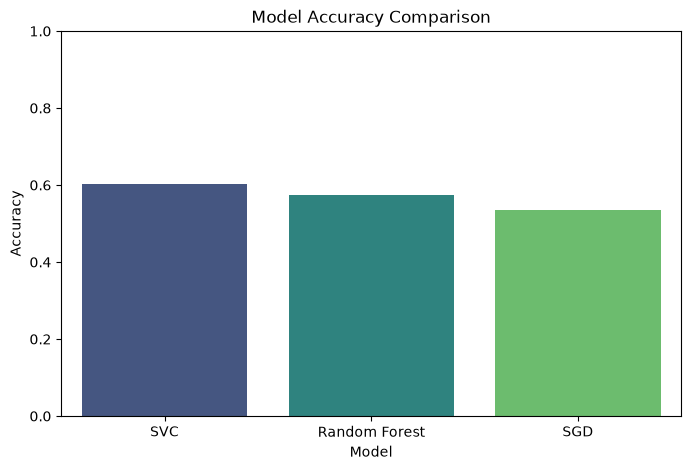

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    legend=False,
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

plt.show()